In [1]:
from datasets import load_dataset
from custom_tokenizers.GPETokenizer import GPETokenizer

In [2]:
ds = load_dataset("Helsinki-NLP/opus-100", "en-si", cache_dir="./hf_cache")

In [3]:
train_texts_si = [ex["si"] for ex in ds["train"]["translation"]]

In [4]:
train_texts_en = [ex["en"] for ex in ds["train"]["translation"]]

In [ ]:
tokenizer = GPETokenizer(vocab_size=4000)

tokenizer.train(train_texts_si[:1000])

In [5]:
# 2. Encode text to token IDs
text = "මම ගෙදර යනවා."
token_ids = tokenizer.encode(text)
print(f"Encoded: {token_ids}")

# 3. Decode token IDs back to text
decoded_text = tokenizer.decode(token_ids)
print(f"Decoded: {decoded_text}")

# 4. Tokenize text into subword strings
tokens = tokenizer.tokenize(text)
print(f"Tokens: {tokens}")

Encoded: [2, 286, 286, 790, 991, 14, 3]
Decoded: මම ගෙදර යනවා.
Tokens: ['ම', 'ම', '▁ගෙදර', '▁යනවා', '.']


In [6]:
tokenizer.save("./tokenizers_trained/gpe_test")

In [9]:
tok = GPETokenizer(vocab_size=4000)
tok.load("./tokenizers_trained/gpe_test")


In [10]:
# 2. Encode text to token IDs
text = "මම ගෙදර යනවා."
token_ids = tok.encode(text)
print(f"Encoded: {token_ids}")

# 3. Decode token IDs back to text
decoded_text = tok.decode(token_ids)
print(f"Decoded: {decoded_text}")

# 4. Tokenize text into subword strings
tokens = tok.tokenize(text)
print(f"Tokens: {tokens}")

Encoded: [2, 286, 286, 790, 991, 14, 3]
Decoded: මම ගෙදර යනවා.
Tokens: ['ම', 'ම', '▁ගෙදර', '▁යනවා', '.']


In [1]:
print("hello world".split())

['hello', 'world']


In [4]:
# Initialize tokenizers
tokenizer_si = GPETokenizer()

tokenizer_si.load("./tokenizers_trained/gpe_si_10m_32k")

In [ ]:
import random

# Pick 10 random samples
random_samples = random.sample(train_texts_si, 50)

print("Tokenizing 10 random samples from train_texts_si:")
for i, sample in enumerate(random_samples):
    print(f"\nSample {i+1}: '{sample}'")
    print(f"Tokenized: {tokenizer_si.tokenize(sample)}")

Tokenizing 10 random samples from train_texts_si:

Sample 1: '... කොහෙද ඔයා අන්තිමට වැඩ කළේ කියලා?'

Sample 2: 'හපලා පෙන්වන්නද.'

Sample 3: 'මම උබලා ඔක්කොගෙම ඔරලෝසු හින්දවනවා ..උබලා කවුරුත් මට ...කියුවේ නැත්නම් ... ... මට ඇහෙන්න ඕනේ දේ.'

Sample 4: 'මට මූව ඕන.'

Sample 5: '-ඇත්තෙන්ම නැහැ.'

Sample 6: '- ජෙරි.'

Sample 7: 'මොකද වුනේ ?'

Sample 8: 'තැටියට අත්හිටුවන්න'

Sample 9: '- ජයවේවා!'

Sample 10: 'මගේ කට පොපියනව.'

Sample 11: 'ඔයා පණපිටින් ඉන්න තරම් වාසනාවන්තයි.'

Sample 12: 'මම ඔයාට රයිඩ් එකක් දෙන්නම්. ඔයා.'

Sample 13: 'ඔයා මගේ දරුවව බලාගන්න.'

Sample 14: 'ඒක මගේ සතුට∙'

Sample 15: 'තව ටිකෙන් ඔයා මුලු කන්දම විනාශ කරනව.'

Sample 16: 'උතුරු ඇමරිකානු ප්‍රෙයාරිය.'

Sample 17: 'Excuse me.'

Sample 18: 'හොදයි.'

Sample 19: 'ඔයාලට බොහොමත්ම ස්තූතියි.'

Sample 20: 'මොකද උනේ, මගේ දරුව?'

Sample 21: '- කළුවරෙ මට මොකුත් පෙවුන් නැ∙'

Sample 22: 'Erik, කියන්න.'

Sample 23: 'කෘතීම ජනගහණ පාලනයක් ස්ථාපනය කෙරුණා.'

Sample 24: 'ඒ උන් ඉතා රසවත් නිසා .'

Sample 25: 'මම ඒ හැම වෙලාවම මායාකාරයෝ වටේ හිටි

In [7]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Split, ByteLevel, Whitespace, Metaspace
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.normalizers import NFKC, Sequence

In [11]:

tokenizer_en_bpe_bytelevel = Tokenizer(BPE(unk_token="[UNK]"))

#whitespace_pattern = r" ?\w+| ?[^\w\s]+"

#tokenizer_en_bpe_bytelevel.pre_tokenizer = ByteLevel()
tokenizer_en_bpe_bytelevel.pre_tokenizer = Metaspace()
#tokenizer_en_bpe_bytelevel.decoder = ByteLevelDecoder()

tokenizer_en_bpe_bytelevel.normalizer = Sequence([
    NFKC()
])


trainer = BpeTrainer(
    vocab_size=32000,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer_en_bpe_bytelevel.train_from_iterator(train_texts_en, trainer=trainer)


In [12]:
tokenizer_en_bpe_bytelevel.save("./tokenizers_trained/bpe_metaspace_en_1m_32k/tokenizer.json")

In [ ]:

tokenizer_si_bpe_whitespace = Tokenizer(BPE(unk_token="[UNK]"))

#whitespace_pattern = r" ?\w+| ?[^\w\s]+"

tokenizer_si_bpe_whitespace.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=32000,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer_si_bpe_whitespace.train_from_iterator(train_texts_si, trainer=trainer)


In [36]:
tokenizer_si_bpe_whitespace.save("./tokenizers_trained/bpe_whitespace_si_1m_32k/tokenizer.json")

In [ ]:
import random

# Pick 10 random samples
random_samples = random.sample(train_texts_en, 50)

print("Tokenizing 10 random samples from train_texts_en:")
for i, sample in enumerate(random_samples):
    print(f"\nSample {i+1}: '{sample}'")
    print(f"Tokenized_BPE: {'|'.join(tokenizer_en_bpe_bytelevel.encode(sample).tokens)}")
    print(f"Tokenized_BPE: {tokenizer_en_bpe_bytelevel.encode(sample).ids}")
    print(f"Tokenized_BPE: {'|'.join(tokenizer_en_bpe_bytelevel.decode(tokenizer_en_bpe_bytelevel.encode(sample).ids))}")
    #print(f"Tokenized GPE: {'|'.join(tokenizer_en.tokenize(sample))}")

In [18]:
tokenizer_si = Tokenizer.from_file("./tokenizers_trained/bpe_bytelevel_si_1m_32k/tokenizer.json")
tokenizer_en = Tokenizer.from_file("./tokenizers_trained/bpe_bytelevel_en_1m_32k/tokenizer.json")

In [23]:
import random

# Pick 10 random samples
random_samples = random.sample(train_texts_si, 50)

print("Tokenizing 10 random samples from train_texts_si:")
for i, sample in enumerate(random_samples):
    print(f"\nSample {i+1}: '{sample}'")
    encoded = tokenizer_si.encode(sample)
    print(f"IDs: {'|'.join(str(id) for id in encoded.ids)}")
    #print(f"Tokenized: {'|'.join(tokenizer_si.decode(encoded.ids)).replace('Ġ', '_')}")
    print(f"Decoded: |{tokenizer_si.decode(encoded.ids).strip()}|")
    #print(f"Tokenized GPE: {'|'.join(tokenizer_si.tokenize(sample))}")

Tokenizing 10 random samples from train_texts_si:

Sample 1: 'ඔහු මිනිස්සුන්ට ගහන්නෙ නෑ.'
IDs: 275|186|188|177|176|177|193|175|193|186|176|175|191|751|175|176|182|202|285
Decoded: |ඔහු මිනිස්සුන්ට ගහන්නෙ නෑ.|

Sample 2: 'ඇපල් ගහ තිබුනේ ගොඩක් ඈතින්, එහෙම නේද?'
IDs: 1899|175|692|208|177|225|186|176|187|212|197|314|175|1105|177|176|249|288|182|183|202|187|194|34
Decoded: |ඇපල් ගහ තිබුනේ ගොඩක් ඈතින්, එහෙම නේද?|

Sample 3: 'පිළිමයේ අනිත් ටිකට මොකද වුනේ?'
IDs: 205|177|243|177|270|187|295|177|185|175|305|177|367|188|197|301|196|186|176|284
Decoded: |පිළිමයේ අනිත් ටිකට මොකද වුනේ?|

Sample 4: 'හේයි!'
IDs: 203|187|180|418
Decoded: |හේයි!|

Sample 5: 'මට ඇත්තටම එළියේ වැඩ වලට ඔයාව ප්‍රයෝජනවත් වෙන්න පුළුවන්.'
IDs: 235|268|175|422|572|177|180|187|196|195|218|438|207|179|178|205|229|269|223|2061|175|196|182|176|175|176|205|186|243|186|247|233
Decoded: |මට ඇත්තටම එළියේ වැඩ වලට ඔයාව ප්‍රයෝජනවත් වෙන්න පුළුවන්.|

Sample 6: 'මල ජරාව සේරම මගේ කටෙත් එක්ක.'
IDs: 714|839|179|178|209|187|333|258|187|428|182|18

Most common token lengths: [(10, 40970), (4, 40965), (8, 39685), (6, 39182), (12, 39032), (11, 38634), (13, 37241), (9, 37200), (14, 37018), (15, 34314)]


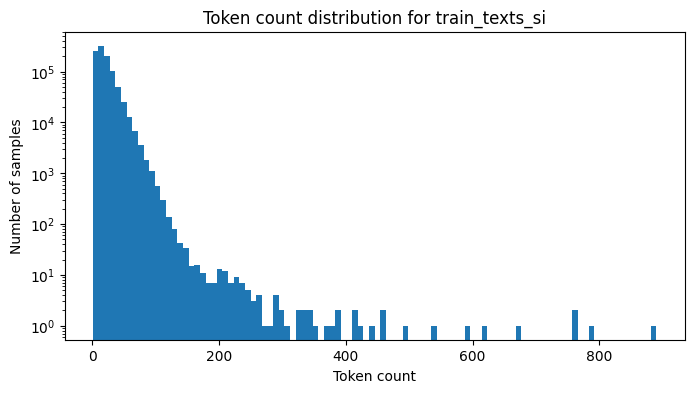

In [25]:
from collections import Counter

import matplotlib.pyplot as plt

# compute token lengths using the Sinhala tokenizer already loaded
lengths = [len(tokenizer_si.encode(t).ids) for t in train_texts_si]
dist = Counter(lengths)

print("Most common token lengths:", dist.most_common(10))

# plot distribution
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=100)
plt.yscale('log')  # log scale helps if there are long tails
plt.title("Token count distribution for train_texts_si")
plt.xlabel("Token count")
plt.ylabel("Number of samples")
plt.show()

In [30]:
#calculate percentage of samples with token count > 128
total_samples = len(train_texts_si)
samples_above_128 = sum(1 for length in lengths if length > 128)
percentage_above_128 = (samples_above_128 / total_samples) * 100
print(f"Number of samples with token count > 128: {samples_above_128}")
print(f"Percentage of samples with token count > 128: {percentage_above_128:.2f}%")

Number of samples with token count > 128: 277
Percentage of samples with token count > 128: 0.03%


In [ ]:
# Load the FLORES dataset for Sinhala and Tamil
flores_ds = load_dataset("facebook/flores", "si-ta", cache_dir="./hf_cache")

# Print the first 5 examples from Sinhala
print("First 5 examples in Sinhala:")
for example in flores_ds["train"][:5]:
    print(example["si"])

# Print the first 5 examples from Tamil
print("\nFirst 5 examples in Tamil:")
for example in flores_ds["train"][:5]:
    print(example["ta"])

RuntimeError: Dataset scripts are no longer supported, but found flores.py

: 